<a href="https://colab.research.google.com/github/gretadive/correlacion_actividad_solar_elnino/blob/main/02_limpieza_oni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limpieza y preparación de datos ONI

Este notebook realiza la carga, validación, transformación y preparación de los datos del Oceanic Niño Index (ONI)

## Fuente de datos

- Variable: Oceanic Niño Index (ONI)
- Región: Niño 3.4
- Fuente: NOAA Climate Prediction Center
- Archivo original: `oni_original.txt`
- Ubicación en GitHub: `data/raw/ONI/`



In [5]:
%cd /content/correlacion_actividad_solar_elnino
!ls data/raw/ONI

/content/correlacion_actividad_solar_elnino
oni_original.txt  README.md


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_oni = pd.read_csv(
    "data/raw/ONI/oni_original.txt",
    sep=r"\s+"
)

df_oni.head()

,SEAS,YR,TOTAL,ANOM
0,DJF,1950,25.01,-1.32
1,JFM,1950,25.36,-1.20
2,FMA,1950,25.88,-1.12
3,MAM,1950,26.24,-1.08
4,AMJ,1950,26.35,-1.10


In [7]:
#convertir cada temporada a su mes central
df_oni = df_oni.rename(columns={
    "SEAS": "temporada",
    "YR": "anio",
    "TOTAL": "sst_nino34",
    "ANOM": "ONI"
})

df_oni.head()

,temporada,anio,sst_nino34,ONI
0,DJF,1950,25.01,-1.32
1,JFM,1950,25.36,-1.20
2,FMA,1950,25.88,-1.12
3,MAM,1950,26.24,-1.08
4,AMJ,1950,26.35,-1.10


In [9]:
mes_central = {
    "DJF": 1,
    "JFM": 2,
    "FMA": 3,
    "MAM": 4,
    "AMJ": 5,
    "MJJ": 6,
    "JJA": 7,
    "JAS": 8,
    "ASO": 9,
    "SON": 10,
    "OND": 11,
    "NDJ": 12
}

df_oni["mes"] = df_oni["temporada"].map(mes_central)
df_oni["fecha"] = pd.to_datetime(
    dict(
        year=df_oni["anio"],
        month=df_oni["mes"],
        day=1
    )
)

In [18]:
df_oni = df_oni[ #ordenar las columnas
    ["fecha", "anio", "mes", "temporada", "sst_nino34", "ONI"]
]

df_oni.head(12)

,fecha,anio,mes,temporada,sst_nino34,ONI
0,1950-01-01,1950,1,DJF,25.01,-1.32
1,1950-02-01,1950,2,JFM,25.36,-1.20
2,1950-03-01,1950,3,FMA,25.88,-1.12
3,1950-04-01,1950,4,MAM,26.24,-1.08
4,1950-05-01,1950,5,AMJ,26.35,-1.10
5,1950-06-01,1950,6,MJJ,26.32,-0.90
6,1950-07-01,1950,7,JJA,26.24,-0.62
7,1950-08-01,1950,8,JAS,25.94,-0.57
8,1950-09-01,1950,9,ASO,25.76,-0.56
9,1950-10-01,1950,10,SON,25.60,-0.62


In [11]:
print("Dimensiones:", df_oni.shape)

print("\nTipos de datos:")
print(df_oni.dtypes)

print("\nValores faltantes:")
print(df_oni.isnull().sum())

print("\nDuplicados:")
print(df_oni.duplicated().sum())

print("\nPrimer registro:")
print(df_oni.iloc[0])

print("\nÚltimo registro:")
print(df_oni.iloc[-1])

Dimensiones: (919, 6)

Tipos de datos:
fecha         datetime64[ns]
anio                   int64
mes                    int64
temporada             object
sst_nino34           float64
ONI                  float64
dtype: object

Valores faltantes:
fecha         0
anio          0
mes           0
temporada     0
sst_nino34    0
ONI           0
dtype: int64

Duplicados:
0

Primer registro:
fecha         1950-01-01 00:00:00
anio                         1950
mes                             1
temporada                     DJF
sst_nino34                  25.01
ONI                         -1.32
Name: 0, dtype: object

Último registro:
fecha         2026-07-01 00:00:00
anio                         2026
mes                             7
temporada                     JJA
sst_nino34                  29.09
ONI                           1.8
Name: 918, dtype: object


In [12]:
df_oni.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       919 non-null    datetime64[ns]
 1   anio        919 non-null    int64         
 2   mes         919 non-null    int64         
 3   temporada   919 non-null    object        
 4   sst_nino34  919 non-null    float64       
 5   ONI         919 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 43.2+ KB


In [13]:
#verificar continuidad mensual
df_oni = df_oni.sort_values("fecha").reset_index(drop=True)

fechas_esperadas = pd.date_range(
    start=df_oni["fecha"].min(),
    end=df_oni["fecha"].max(),
    freq="MS"
)

fechas_faltantes = fechas_esperadas.difference(df_oni["fecha"])

print("Total de registros:", len(df_oni))
print("Fechas duplicadas:", df_oni["fecha"].duplicated().sum())
print("Meses faltantes:", len(fechas_faltantes))
print("Periodo:", df_oni["fecha"].min(), "a", df_oni["fecha"].max())

Total de registros: 919
Fechas duplicadas: 0
Meses faltantes: 0
Periodo: 1950-01-01 00:00:00 a 2026-07-01 00:00:00


In [19]:
df_oni.to_csv(
    "data/processed/oni_procesado.csv",
    index=False,
    encoding="utf-8"
)

print("✅ ONI procesado guardado correctamente")

✅ ONI procesado guardado correctamente


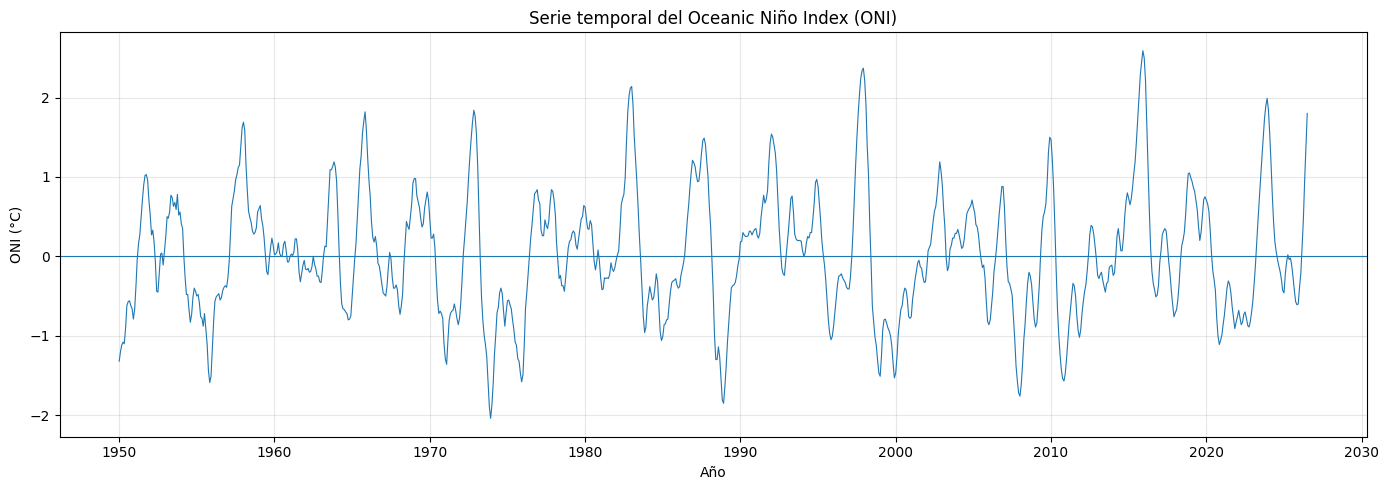

In [15]:
plt.figure(figsize=(14,5))

plt.plot(
    df_oni["fecha"],
    df_oni["ONI"],
    linewidth=0.8
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Año")
plt.ylabel("ONI (°C)")
plt.title("Serie temporal del Oceanic Niño Index (ONI)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/serie_temporal_oni.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
!git config user.name "gretadive"
!git config user.email "gretadive@users.noreply.github.com"
!git status
!git add data/processed/oni_procesado.csv
!git add figures/serie_temporal_oni.png
!git commit -m "Procesar datos ONI y agregar serie temporal"


On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   data/processed/oni_procesado.csv
	new file:   figures/serie_temporal_oni.png

[main 68139f3] Procesar datos ONI y agregar serie temporal
 2 files changed, 920 insertions(+)
 create mode 100644 data/processed/oni_procesado.csv
 create mode 100644 figures/serie_temporal_oni.png


In [25]:
from google.colab import userdata
import subprocess
import base64

token = userdata.get("GITHUB_TOKEN")
usuario = "gretadive"

credenciales = base64.b64encode(
    f"{usuario}:{token}".encode()
).decode()

resultado = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=Authorization: Basic {credenciales}",
        "push",
        "origin",
        "main"
    ],
    capture_output=True,
    text=True
)

if resultado.returncode == 0:
    print("✅ ONI enviado correctamente a GitHub")
else:
    print("❌ Error:")
    print(resultado.stderr)

✅ ONI enviado correctamente a GitHub
